<a href="https://colab.research.google.com/github/Snjkmr162/The_Pricing_Analytics_Toolkit/blob/main/notebooks/week2_markdown/Week2_Markdown_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob

In [6]:
from google.colab import files
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)

Saving kaggle.json to kaggle (1).json


In [7]:
kaggle_files = glob.glob('/content/kaggle*.json')
print(f"Found: {kaggle_files}")
!cp "{kaggle_files[0]}" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

!pip install -q kaggle
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d walmart_data
!unzip -o walmart_data/train.csv.zip -d walmart_data
!unzip -o walmart_data/test.csv.zip -d walmart_data
!unzip -o walmart_data/features.csv.zip -d walmart_data

train = pd.read_csv("walmart_data/train.csv", parse_dates=["Date"])
features = pd.read_csv("walmart_data/features.csv", parse_dates=["Date"])
stores = pd.read_csv("walmart_data/stores.csv")

df = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores, on="Store", how="left")

print(f"Data loaded: {df.shape}")

Found: ['/content/kaggle.json', '/content/kaggle (1).json']
100% 2.70M/2.70M [00:00<00:00, 178MB/s]

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: walmart_data/features.csv.zip  
  inflating: walmart_data/sampleSubmission.csv.zip  
  inflating: walmart_data/stores.csv  
  inflating: walmart_data/test.csv.zip  
  inflating: walmart_data/train.csv.zip  
Archive:  walmart_data/train.csv.zip
  inflating: walmart_data/train.csv  
Archive:  walmart_data/test.csv.zip
  inflating: walmart_data/test.csv   
Archive:  walmart_data/features.csv.zip
  inflating: walmart_data/features.csv  
Data loaded: (421570, 16)


In [8]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

print("Markdown data availability:")
for col in markdown_cols:
    non_null = features[col].notna().sum()
    total = len(features)
    pct = non_null / total * 100
    print(f"  {col}: {non_null:,} non-null rows out of {total:,} ({pct:.1f}%)")

print(f"\nEarliest markdown date: {features[features['MarkDown1'].notna()]['Date'].min()}")
print(f"Latest markdown date:   {features[features['MarkDown1'].notna()]['Date'].max()}")

print("\nMarkdown value ranges:")
print(features[markdown_cols].describe().round(2))

Markdown data availability:
  MarkDown1: 4,032 non-null rows out of 8,190 (49.2%)
  MarkDown2: 2,921 non-null rows out of 8,190 (35.7%)
  MarkDown3: 3,613 non-null rows out of 8,190 (44.1%)
  MarkDown4: 3,464 non-null rows out of 8,190 (42.3%)
  MarkDown5: 4,050 non-null rows out of 8,190 (49.5%)

Earliest markdown date: 2011-11-11 00:00:00
Latest markdown date:   2013-07-26 00:00:00

Markdown value ranges:
       MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5
count    4032.00    2921.00    3613.00    3464.00    4050.00
mean     7032.37    3384.18    1760.10    3292.94    4132.22
std      9262.75    8793.58   11276.46    6792.33   13086.69
min     -2781.45    -265.76    -179.26       0.22    -185.17
25%      1577.53      68.88       6.60     304.69    1440.83
50%      4743.58     364.57      36.26    1176.42    2727.14
75%      8923.31    2153.35     163.15    3310.01    4832.56
max    103184.98  104519.54  149483.31   67474.85  771448.10


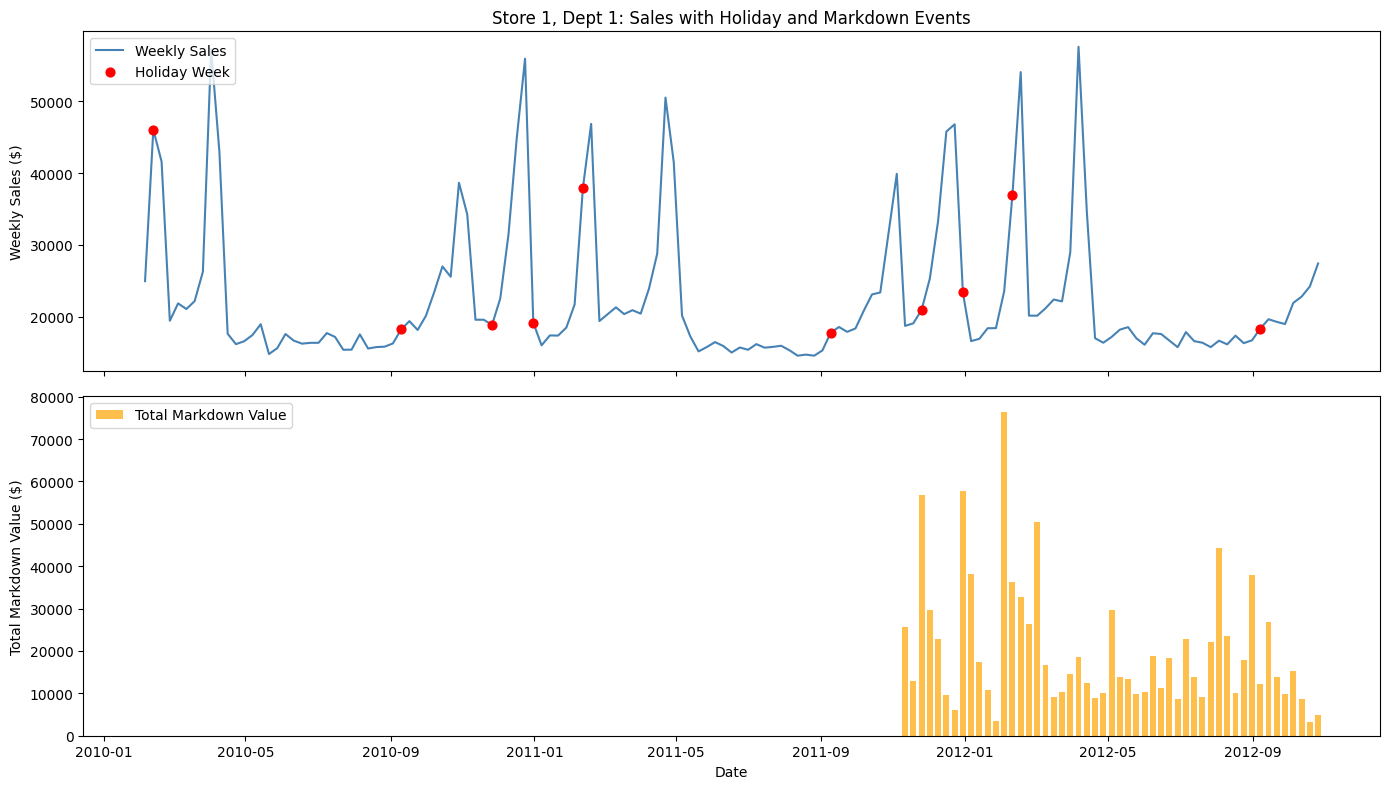

In [9]:
store_data = df[(df["Store"] == 1) & (df["Dept"] == 1)].copy()
store_data = store_data.sort_values("Date").reset_index(drop=True)

# Create a combined markdown indicator
store_data["Total_Markdown"] = store_data[markdown_cols].sum(axis=1)
store_data["Has_Markdown"] = store_data["Total_Markdown"] > 0

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Weekly sales with holiday flags
axes[0].plot(store_data["Date"], store_data["Weekly_Sales"],
             color="steelblue", linewidth=1.5, label="Weekly Sales")
axes[0].scatter(store_data[store_data["IsHoliday"]]["Date"],
                store_data[store_data["IsHoliday"]]["Weekly_Sales"],
                color="red", zorder=5, label="Holiday Week", s=40)
axes[0].set_ylabel("Weekly Sales ($)")
axes[0].set_title("Store 1, Dept 1: Sales with Holiday and Markdown Events")
axes[0].legend(loc="upper left")

# Bottom: Total markdown value over time
axes[1].bar(store_data["Date"], store_data["Total_Markdown"],
            color="orange", alpha=0.7, width=5, label="Total Markdown Value")
axes[1].set_ylabel("Total Markdown Value ($)")
axes[1].set_xlabel("Date")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.savefig("week2_day6_markdown_overview.png", dpi=150)
plt.show()

In [10]:
holiday_sales = store_data[store_data["IsHoliday"]]["Weekly_Sales"]
non_holiday_sales = store_data[~store_data["IsHoliday"]]["Weekly_Sales"]
markdown_sales = store_data[store_data["Has_Markdown"]]["Weekly_Sales"]
no_markdown_sales = store_data[~store_data["Has_Markdown"]]["Weekly_Sales"]

print("Sales comparison (Store 1, Dept 1):")
print(f"  Average holiday week sales:     ${holiday_sales.mean():,.0f}")
print(f"  Average non-holiday week sales: ${non_holiday_sales.mean():,.0f}")
print(f"  Holiday lift:                   {(holiday_sales.mean() / non_holiday_sales.mean() - 1):.1%}")
print(f"\n  Average markdown week sales:    ${markdown_sales.mean():,.0f}")
print(f"  Average no-markdown week sales: ${no_markdown_sales.mean():,.0f}")
print(f"  Markdown lift:                  {(markdown_sales.mean() / no_markdown_sales.mean() - 1):.1%}")

Sales comparison (Store 1, Dept 1):
  Average holiday week sales:     $25,739
  Average non-holiday week sales: $22,271
  Holiday lift:                   15.6%

  Average markdown week sales:    $22,641
  Average no-markdown week sales: $22,443
  Markdown lift:                  0.9%
